# 03 — Grid Snapping and the Feistel PRP

## Act 1: Grid Snapping

After projecting (lat, lon) to (x, y) in metres, we quantise to the nearest 250 m grid tile:

```
qx = round(x / bin)     qy = round(y / bin)
rx = x - qx * bin       ry = y - qy * bin
```

The residual `(rx, ry)` is always in **(-125, +125) m** — the full sub-tile precision of the original GPS fix. Storing `(qx, qy)` in plain text would reveal the 250 m tile; that is why we need to shuffle it.

## Act 2 Preview: The Permutation Requirement

We need to map every tile index `(qx, qy)` to an encrypted index `(qxp, qyp)` such that:
1. No two tiles map to the same encrypted tile (injectivity).
2. The mapping is reversible (surjectivity over the same finite set).
3. The mapping is keyed and computationally indistinguishable from random.

A keyed bijection on a finite set is a **pseudorandom permutation (PRP)**. The Feistel network construction guarantees this.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Pipeline step 2 of 4 — Grid snapping and Feistel PRP</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:500;font-size:13px;">① Project</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:700;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:500;font-size:13px;">③ Lock</div></div>
    <div style="background:#dff0ee;color:#3d7a71;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:500;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Define** tile quantisation and state the purpose of `bin_size_m` in converting projected coordinates to integer tile indices.
2. **Describe** the Feistel round structure and explain why alternating left–right mixing guarantees a bijection over the tile-index domain.
3. **Demonstrate** the PRP encryption step manually for a Broadwick Street pump coordinate and verify the result matches `_prp_encrypt`.
4. **Differentiate** between the plaintext tile indices `(qx, qy)` and the PRP-shuffled indices `(qxp, qyp)` stored in the encrypted record.
5. **Construct** a rejection-sampling argument for why the Feistel PRP must operate over a power-of-two domain rather than the exact tile count.

In [1]:
import math
import struct
import hashlib
import secrets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from map_encryption import (
    _project, _unproject, _grid_range, _prp_encrypt, _prp_decrypt,
    _prf_upto, SchemeParams, _R_EARTH,
)

def metres_to_deg(spread_m, at_lat):
    lat_deg = spread_m / 111_320
    lon_deg = spread_m / (111_320 * math.cos(math.radians(at_lat)))
    return lat_deg, lon_deg

params = SchemeParams()
BIN = params.bin_size_m
CENTER_LAT, CENTER_LON = 51.513341, -0.136668  # Broadwick Street pump, Soho, London (1854 cholera outbreak)

In [2]:
x_ts, y_ts = _project(CENTER_LAT, CENTER_LON)
qx = int(round(x_ts / BIN))
qy = int(round(y_ts / BIN))
rx = x_ts - qx * BIN
ry = y_ts - qy * BIN

print(f'Broadwick Street pump projection:')
print(f'  x = {x_ts:.3f} m,  y = {y_ts:.3f} m')
print(f'  qx = {qx},  qy = {qy}')
print(f'  rx = {rx:.4f} m,  ry = {ry:.4f} m')

assert abs(rx) < 125, f'rx={rx} outside tile half-width'
assert abs(ry) < 125, f'ry={ry} outside tile half-width'
print('Residual is within tile half-width: OK')

Broadwick Street pump projection:
  x = -15213.812 m,  y = 6712605.101 m
  qx = -61,  qy = 26850
  rx = 36.1878 m,  ry = 105.1006 m
Residual is within tile half-width: OK


In [3]:
min_q, M = _grid_range(BIN)
print(f'Grid range: min_q = {min_q},  M = {M}')
print(f'Total cells: M^2 = {M**2:,}')

print('\n5x5 grid of (qx, qy) tiles near Broadwick Street pump and their back-projected coords:')
print(f'{"(qx,qy)":<20} {"lat":>10} {"lon":>12}')
for dqy in range(-2, 3):
    for dqx in range(-2, 3):
        tqx, tqy = qx + dqx, qy + dqy
        tlat, tlon = _unproject(tqx * BIN, tqy * BIN)
        print(f'  ({tqx},{tqy})            {tlat:>10.6f} {tlon:>12.6f}')

Grid range: min_q = -80151,  M = 160302
Total cells: M^2 = 25,696,731,204

5x5 grid of (qx, qy) tiles near Broadwick Street pump and their back-projected coords:
(qx,qy)                     lat          lon
  (-63,26848)             51.509958    -0.141485
  (-62,26848)             51.509958    -0.139239
  (-61,26848)             51.509958    -0.136993
  (-60,26848)             51.509958    -0.134747
  (-59,26848)             51.509958    -0.132502
  (-63,26849)             51.511356    -0.141485
  (-62,26849)             51.511356    -0.139239
  (-61,26849)             51.511356    -0.136993
  (-60,26849)             51.511356    -0.134747
  (-59,26849)             51.511356    -0.132502
  (-63,26850)             51.512753    -0.141485
  (-62,26850)             51.512753    -0.139239
  (-61,26850)             51.512753    -0.136993
  (-60,26850)             51.512753    -0.134747
  (-59,26850)             51.512753    -0.132502
  (-63,26851)             51.514151    -0.141485
  (-62,26

## Why the Mapping Must Be a Bijection

If two tiles `(qx1, qy1)` and `(qx2, qy2)` mapped to the same encrypted tile `(qxp, qyp)`, decryption would be ambiguous — we would not know which original tile to recover. A PRP avoids this by construction: it is a **bijection** (one-to-one and onto) on the tile index set.

**Feistel round structure** (one round):
```
L_new = (L + F(R, key, tweak, round)) mod M
(L, R) = (R, L_new)    # swap
```
Regardless of `F`, reversing the swap and then subtracting `F(R, ...)` recovers the original. Even a non-invertible `F` produces an invertible round — that is the Feistel trick. After ≥ 4 rounds the composition is a PRP (Luby & Rackoff, 1988).

## Rejection Sampling for Unbiased PRF Output

Naive `hash % M` is **biased** when `2^256 mod M ≠ 0`. Suppose `2^256 = k*M + r` with `r > 0`. Values in `[0, r)` are hit `k+1` times; values in `[r, M)` only `k` times. Over millions of records, this creates a **frequency fingerprint**: an attacker observing encrypted tile indices can distinguish slightly-more-frequent values from slightly-less-frequent ones.

**Rejection sampling** fixes this:
```
cutoff = floor(2^256 / M) * M
loop:
    h = BLAKE2s(key, data + counter)
    val = int.from_bytes(h, 'big')
    if val < cutoff: return val % M
    counter += 1
```
Rejection probability `< M / 2^256 ≈ 6×10⁻⁷²` — virtually impossible. The result is exactly uniform over `[0, M)`.

In [4]:
min_q, M = _grid_range(BIN)
fixed_key = hashlib.blake2s(b'nb03-prf-demo', digest_size=32).digest()

cutoff = ((1 << 256) // M) * M
print(f'M = {M},  cutoff = {cutoff}')
print()

for i in range(3):
    data = struct.pack('>I', i)
    h = hashlib.blake2s(key=fixed_key, digest_size=32)
    h.update(data + struct.pack('>I', 0))
    raw = int.from_bytes(h.digest(), 'big')
    result = _prf_upto(fixed_key, data, M)
    accepted = raw < cutoff
    print(f'input={i}: raw_hash={raw} (accepted={accepted}), result={result}')
    assert 0 <= result < M, f'result {result} out of range [0, {M})'

print('\nAll results in [0, M): OK')

M = 160302,  cutoff = 115792089237316195423570985008687907853269984665640564039457584007913129538052

input=0: raw_hash=62063294506474534406807778697367844746765763659134447517792861568967532039976 (accepted=True), result=81864
input=1: raw_hash=95845104314074709888036525528181289095128042645880492658927600999069123810873 (accepted=True), result=78097
input=2: raw_hash=76660543974569812697702030828215209556824024407919041361775988918881059455720 (accepted=True), result=51776

All results in [0, M): OK


In [5]:
test_key = hashlib.blake2s(b'nb03-test', digest_size=32).digest()
test_tweak = b'nb03-demo'
min_q, M = _grid_range(BIN)

# Manual Feistel trace (4 rounds)
L, Rv = qx - min_q, qy - min_q
print(f'Initial (L, R) = ({L}, {Rv})')
for r in range(4):
    F = _prf_upto(test_key, test_tweak + struct.pack('>II', r, Rv), M)
    L = (L + F) % M
    L, Rv = Rv, L
    print(f'After round {r}: F={F}, (L, R) = ({L}, {Rv})')

# Undo the implicit final swap for 4 rounds (even number)
manual_qxp = L + min_q
manual_qyp = Rv + min_q

# Verify against _prp_encrypt (using 4 rounds via params override)
lib_qxp, lib_qyp = _prp_encrypt(qx, qy, test_key, test_tweak, BIN, 4)
print(f'\nManual result:  qxp={manual_qxp}, qyp={manual_qyp}')
print(f'Library result: qxp={lib_qxp}, qyp={lib_qyp}')
assert (manual_qxp, manual_qyp) == (lib_qxp, lib_qyp), 'Mismatch!'
print('Manual Feistel trace matches _prp_encrypt: OK')

Initial (L, R) = (80090, 107001)
After round 0: F=135114, (L, R) = (107001, 54902)
After round 1: F=3643, (L, R) = (54902, 110644)
After round 2: F=123291, (L, R) = (110644, 17891)
After round 3: F=156841, (L, R) = (17891, 107183)

Manual result:  qxp=-62260, qyp=27032
Library result: qxp=-62260, qyp=27032
Manual Feistel trace matches _prp_encrypt: OK


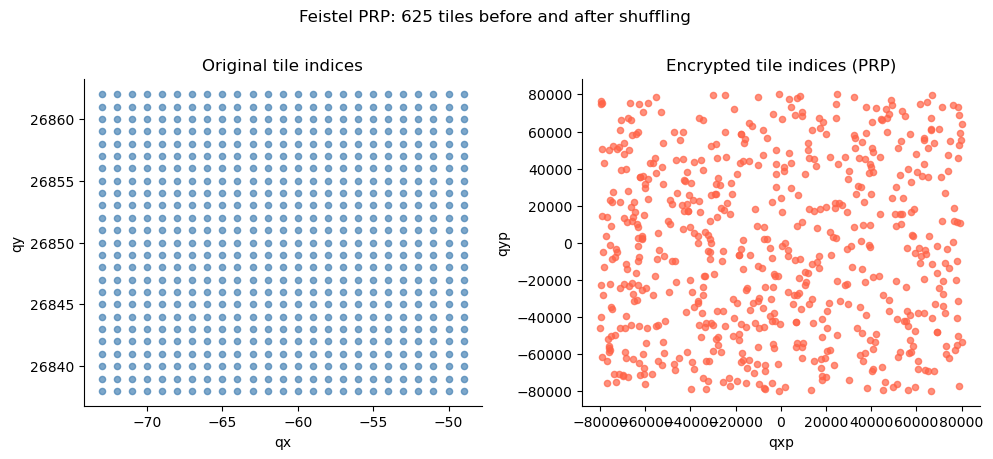

In [6]:
# PRP scatter: 25x25 = 625 tiles
prp_key   = hashlib.blake2s(b"nb03-scatter", digest_size=32).digest()
prp_tweak = b"nb03-demo"

orig_qx, orig_qy, enc_qxp, enc_qyp = [], [], [], []
for dqx in range(-12, 13):
    for dqy in range(-12, 13):
        tqx, tqy = qx + dqx, qy + dqy
        tqxp, tqyp = _prp_encrypt(tqx, tqy, prp_key, prp_tweak, BIN, 10)
        orig_qx.append(tqx);  orig_qy.append(tqy)
        enc_qxp.append(tqxp); enc_qyp.append(tqyp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
ax1.scatter(orig_qx, orig_qy, c="steelblue", s=20, alpha=0.7)
ax1.set_title("Original tile indices"); ax1.set_xlabel("qx"); ax1.set_ylabel("qy")

ax2.scatter(enc_qxp, enc_qyp, c="tomato", s=20, alpha=0.7)
ax2.set_title("Encrypted tile indices (PRP)"); ax2.set_xlabel("qxp"); ax2.set_ylabel("qyp")

fig.suptitle("Feistel PRP: 625 tiles before and after shuffling", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 3a.** Scatter plot of 625 tile indices before (blue) and after (orange) Feistel PRP permutation over a 25 × 25 grid, illustrating that the bijection redistributes tiles pseudo-randomly while preserving the full index domain.

In [7]:
import pandas as pd
import folium

deaths = pd.read_csv('data/cholera_deaths.csv')

# Show 250 actual death locations and their snapped 250 m tile centres.
# Deaths are tightly clustered around the Broadwick Street pump — the 250 m bins
# capture neighbourhood-level precision while coarsening exact addresses.
rows = []
for _, row in deaths.iterrows():
    lat, lon = row['LAT'], row['LON']
    x_i, y_i = _project(lat, lon)
    tqx = int(round(x_i / BIN))
    tqy = int(round(y_i / BIN))
    snap_lat, snap_lon = _unproject(tqx * BIN, tqy * BIN)
    rows.append({'lat': lat,      'lon': lon,      'type': 'original'})
    rows.append({'lat': snap_lat, 'lon': snap_lon, 'type': 'snapped (tile centre)'})

colors = {'original': 'steelblue', 'snapped (tile centre)': 'orange'}
m = folium.Map(location=[51.513, -0.136], zoom_start=15, tiles='cartodbpositron')
for row in rows:
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=colors[row['type']],
        fill=True,
        fill_color=colors[row['type']],
        fill_opacity=0.7,
        tooltip=row['type'],
    ).add_to(m)
m


**Figure 3b.** Folium map of all 250 cholera death locations snapped to their nearest 250 m tile centres, centred on the Broadwick Street pump in Soho.

## What Snapping + PRP Protect — and Don't

**Protected by snapping:** GPS precision is coarsened to ±125 m; even knowing (qx, qy), an adversary cannot determine the exact position within the tile.

**Protected by PRP:** Without the PRP key, (qxp, qyp) reveals no information about which tile was originally visited — including which country or continent.

**Not yet protected:** The residual `(rx, ry)` is still in plaintext at this stage. It carries the full within-tile precision of the original GPS fix. NB04 shows how AEAD encryption seals this final piece of information.

## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Luby, M., & Rackoff, C.** (1988). How to construct pseudorandom permutations from pseudorandom functions. *SIAM Journal on Computing, 17*(2), 373–386. — Proof that ≥ 4 Feistel rounds produce a PRP.
- **Aumasson, J.-P., Neves, S., Wilcox-O'Halon, Z., & Winnerlein, C.** (2013). BLAKE2: simpler, smaller, fast as MD5. *ACNS 2013*, LNCS 7954, 119–135. — BLAKE2s is the PRF used for key derivation, the Feistel round function, and display jitter.

## Glossary

| Term | Definition |
|------|-----------|
| **Grid snapping** | Rounding projected (x, y) coordinates to the nearest multiple of `bin_size_m` to assign each point to a tile. |
| **Tile** | A square cell of side `bin_size_m` (default 250 m) in projected space; the unit of spatial resolution for the encryption scheme. |
| **Tile index (qx, qy)** | Integer coordinates identifying a tile; computed as `round(x / bin_size_m)`, `round(y / bin_size_m)`. |
| **Residual (rx, ry)** | The sub-tile offset `(x − qx·bin, y − qy·bin)`; always within ±125 m of the tile centre; carries full GPS precision. |
| **Pseudorandom permutation (PRP)** | A keyed bijection on a finite set that is computationally indistinguishable from a uniformly random permutation; used here to shuffle tile indices. |
| **Feistel network** | A construction that builds an invertible function (a PRP) from any non-invertible round function; guarantees reversibility regardless of the round function. |
| **Bijection** | A function that is both injective (no two inputs share an output) and surjective (every output has an input); required so that decryption is unambiguous. |
| **Pseudorandom function (PRF)** | A keyed function whose outputs are computationally indistinguishable from random; used as the Feistel round function via BLAKE2s. |
| **Rejection sampling** | A technique to produce a uniform random value in `[0, M)` from a hash output by discarding values ≥ `⌊2²⁵⁶/M⌋·M`, eliminating modular bias. |
| **Shuffled tile index (qxp, qyp)** | The PRP-encrypted tile index stored in the record; reveals no geographic information without `prp_key`. |